## Setup

### Import Libraries

Run the cell blow to import the libraries used in this notebook.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

### Utility Functions

Run the cell below to load the utility functions you are going to use in the exercises.

In [ ]:
def _compute_psth(spikes, onsets, t_window=200, t_bin=10):
    n_bins  = t_window // t_bin 
    edges   = np.arange(0, t_window + t_bin, t_bin)
    psth = np.zeros((len(spikes), n_bins))
    for i, spk in enumerate(spikes):
        for t0 in onsets:
            rel = spk - t0
            counts, _ = np.histogram(rel, bins=edges)
            psth[i] += counts
    psth /= len(onsets)
    return psth, edges

def _plot_psth(psth, bin_edges):
    plt.figure(figsize=(8,4))
    im = plt.imshow(psth, aspect='auto', vmin=0, cmap="hot")
    plt.colorbar(im, label='Mean spike count')
    plt.xlabel("Time [ms]")
    plt.ylabel("Neuron")
    step_size = psth.shape[-1] // 10
    plt.xticks(np.arange(psth.shape[1], step=step_size), labels = bin_edges[:-1:step_size])

class utils:
    compute_psth = _compute_psth
    plot_psth = _plot_psth

### Download Data

Run the cell below to download the dataset used in this notebook and save them in the `/data` subdirectory.

In [ ]:
import requests
from pathlib import Path

urls = [
    "https://uni-bonn.sciebo.de/s/9zsPQMSomsQSiWy",
    "https://uni-bonn.sciebo.de/s/MBAHPczP5x24RoS",
    "https://uni-bonn.sciebo.de/s/en6J6ddLsfWrW6b"
]
names = ["center_out.npy", "network_spikes.npy", "network_stim_on.npy"]

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

print("Downloading Data ...")
for url, name in zip(urls, names):
    fname = data_dir / name
    tmp_name = fname.with_suffix(".download")

    response = requests.get(f"{url}/download", timeout=60)
    response.raise_for_status()
    tmp_name.write_bytes(response.content)

    # Refuse to save server error pages or other non-NPY content as the dataset.
    with open(tmp_name, "rb") as file:
        magic = file.read(6)

    if magic != b"\x93NUMPY":
        tmp_name.unlink(missing_ok=True)
        raise ValueError(
            "Downloaded file is not a valid .npy file. The server may have returned an error page instead."
        )

    tmp_name.replace(fname)

print("Done!")

Done!


## Exploring the PMd Reach-Planning Dataset

In this notebook, we will work with spike count data recorded from **97 neurons in dorsal premotor cortex (PMd)** of a macaque monkey while it planned arm reaches to 8 different target directions.  The file `center_out.npy` contains a $728 \times 97$ matrix. Each row is one 200 ms planning-period spike count vector across all recorded neurons. There are 91 trials for each of the 8 reaching angles, giving $91 \times 8 = 728$ rows. Rows 0–90 correspond to reaching angle 1, rows 91–181 to angle 2, and so on. The neural data have been generously provided by the laboratory of Prof. Krishna Shenoy at Stanford University. The data are to be used exclusively for educational purposes in this course.

The purpose of this section is to familiarize yourself with the data. Using histograms and bar plots we'll look at the distribution of spike counts across trials and neurons and check whether individual neurons respond selectively to a given reaching angle.

### Code Reference

| Code | Description |
| --- | --- |
| `X[trial_idx]` | Spike counts for one trial across all neurons |
| `X[:, neuron_idx]` | Spike counts for one neuron across all trials |
| `X.mean(axis=1)` | Average across neurons, giving one mean per trial |
| `X.mean(axis=0)` | Average across trials, giving one mean per neuron |
| `X_c = X - X.mean(axis=0)` | Mean-center each neuron by subtracting its average firing rate |
| `X.reshape(n_angles, -1, n_neurons)` | Reshape grouped trials into `(angle, trial, neuron)` |
| `X_3d[:, :, neuron_idx].mean(axis=1)` | Average one neuron's firing rate across trials for each angle |
| `plt.hist(...)`, `plt.bar(...)` | Plot distributions and angle tuning curves |

### Exercises


Run the cell below to load the data and print the number of trials and neurons

In [ ]:
X = np.load("data/center_out.npy")
f"n_trials, n_neurons: {X.shape}"

'n_trials, n_neurons: (728, 97)'

**Example**: Visualize the distribution of spike counts across neurons for trial `0` in a histogram.

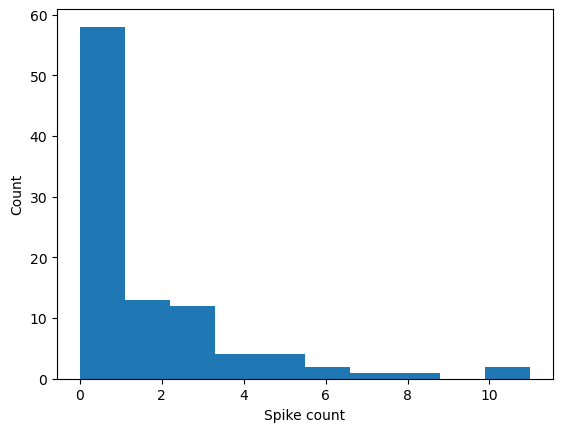

In [ ]:
plt.hist(X[0])
plt.xlabel("Spike count")
plt.ylabel("Count");

**Exercise**: Visualize the distribution of spike counts across neurons for trial `1` in a histogram.

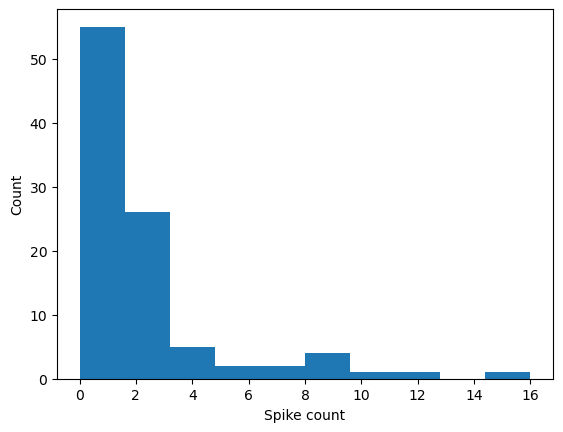

In [ ]:
plt.hist(X[1])
plt.xlabel("Spike count")
plt.ylabel("Count");

**Exercise**: Visualize the distribution of spike counts across trials for neuron `0` (**Hint**: neurons are represented in the second dimension of `X`).

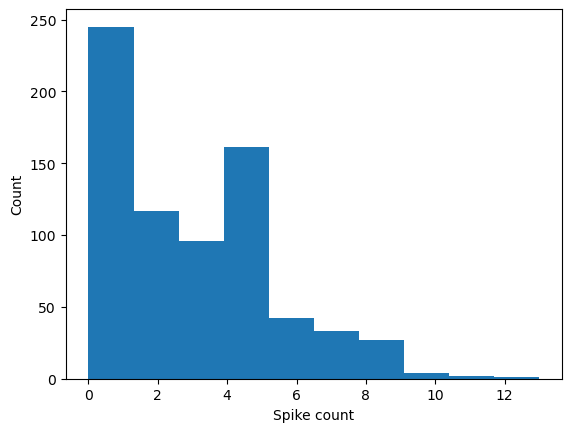

In [ ]:
plt.hist(X[:,0])
plt.xlabel("Spike count")
plt.ylabel("Count");

**Example**: Compute the average spike count per neuron by taking the average across trials (i.e. the first dimension of `X`) and plot a histogram.

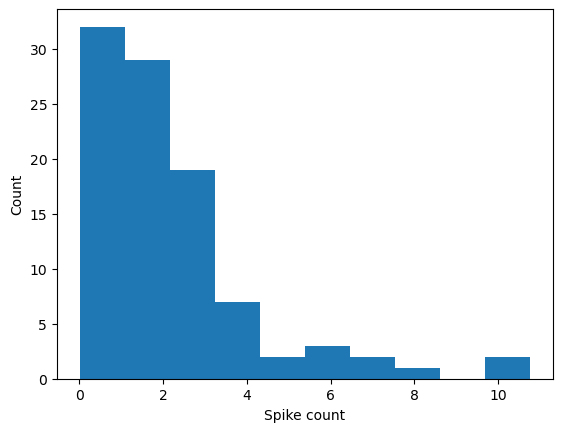

In [ ]:
avg_spikes_per_neuron = X.mean(axis=0)

plt.hist(avg_spikes_per_neuron)
plt.xlabel("Spike count");
plt.ylabel("Count");

The plot above shows that some neurons have much higher average firing rates than others. This is a problem for PCA because, without preprocessing, the first component can be dominated by the overall mean firing-rate pattern rather than by trial-to-trial variation. To prevent this we have to mean-center the data.

**Exercise**: Center the data by subtracting each neuron's mean spike count from `X`. Plot a histogram with the average spike count on the mean centered data to verify all values are close to 0.


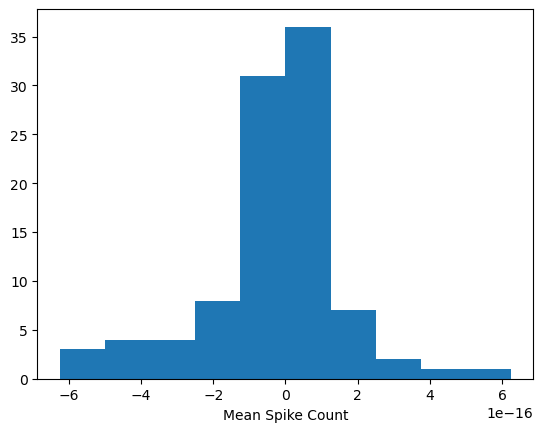

In [ ]:
X_c = X - X.mean(axis=0)
plt.hist(X_c.mean(axis=0))
plt.xlabel("Mean Spike Count");

So far, we analyzed average firing rates across all conditions but we are interested in finding differences across reaching angles. The data in `X` are already organized by condition along the trial dimension so rows 0-90 correspond to angle 1, rows 91-181 to angle 2 and so on. This means we can simply reshape `X` to a 3D matrix `X_3d` of shape `(n_angles, n_trials, n_neurons)`.

In [ ]:
n_angles = 8
n_neurons = X.shape[1]
X_3d = X.reshape(n_angles, -1, n_neurons)

f"n_angles, n_trials, n_neurons: {X_3d.shape}"

'n_angles, n_trials, n_neurons: (8, 91, 97)'

**Example**: Visualize the average firing rate for neuron `0` for every reaching angle in a bar plot. It appears that this neuron fires most strongly for reaching angles 1, 2 and 3.

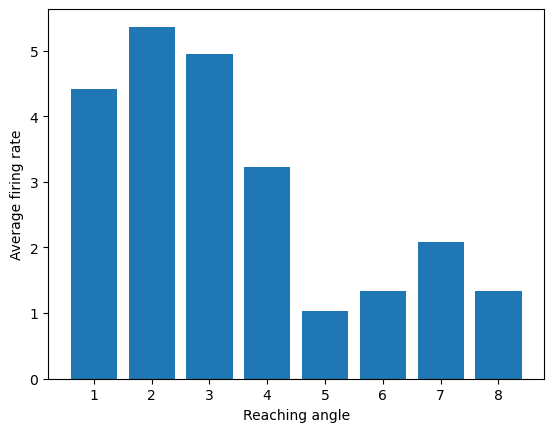

In [ ]:
plt.bar(x=np.arange(1, 9), height=X_3d[:, :, 0].mean(axis=1))
plt.xlabel("Reaching angle")
plt.ylabel("Average firing rate");

**Exercise**: Visualize the average firing rate for neuron `2` for every reaching angle in a bar plot. What is this neuron's preferred reaching angle?

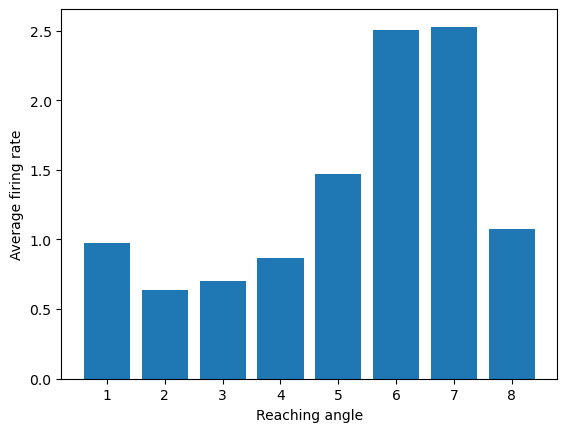

In [ ]:
plt.bar(x=np.arange(1, 9), height=X_3d[:, :, 2].mean(axis=1))
plt.xlabel("Reaching angle")
plt.ylabel("Average firing rate");

**Exercise**: Visualize the average firing rate for neuron `20` for every reaching angle in a bar plot. Does this neuron have a preferred reaching angle?

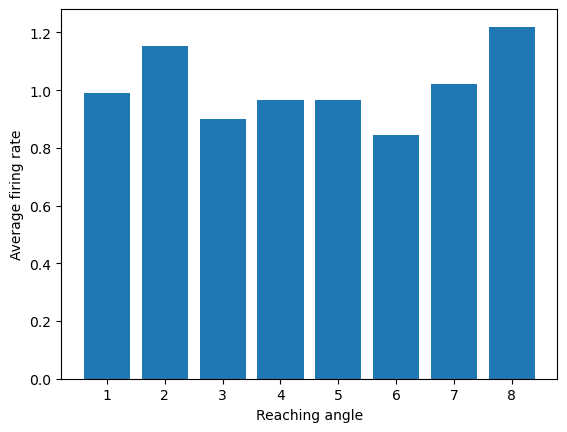

In [ ]:
plt.bar(x=np.arange(1, 9), height=X_3d[:, :, 20].mean(axis=1))
plt.xlabel("Reaching angle")
plt.ylabel("Average firing rate");

It's clear that some of the neurons fire selectively for specific reaching angles. However, with so many observed dimensions, it's hard to grasp what is going on by eye. In the next sections, we are going to use principal component analysis to extract a few components from the data that can explain the differences in the population activity between conditions.

## Computing PCA via Singular Value Decomposition (SVD)

PCA finds a small set of orthogonal directions that capture as much variance as possible in a high-dimensional dataset. In the PMd data, each trial is a point in a 97-dimensional neural activity space, with one dimension per neuron. One efficient way to compute PCA is to apply **singular value decomposition (SVD)** to the mean-centered data matrix:

$$X_c = U S V^T$$

In this factorization, the singular values `S` tell us how much structure each component captures: larger singular values correspond to components that explain more variance in the data. We can convert them into variance explained with $\frac{s_k^2}{n-1}$, where $s_k$ is the singular value of the $k^{th}$ component and $n$ is the number of samples. It is often useful to normalize these values to obtain the percent of variance explained by each component.

The components are sorted by explained variance so when we plot the singular values across components we usually see large values in the beginning and then a steep drop with a long tail.
This is often called a "scree" plot. Scree means a slope of loose rocks or rubble at the base of a mountain because the long tail visually resembles a rocky slope. These plots are very useful for quickly figuring out how many components are needed to capture most of the variance in the data.

### Code Reference

| Code | Description |
| --- | --- |
| `np.linalg.svd(X, full_matrices=False)` | Compute the compact SVD of the uncentered data matrix |
| `np.linalg.svd(X_c, full_matrices=False)` | Compute the compact SVD used for PCA on centered data |
| `U` | Left singular-vector matrix with shape `(n_trials, n_components)` |
| `S` | Singular values, ordered from largest to smallest |
| `Vh` | Right singular-vector matrix with shape `(n_components, n_neurons)` |
| `S**2 / (n_samples - 1)` | Convert singular values into variance explained by each component |
| `100 * var_explained / var_explained.sum()` | Convert variance explained into percent variance explained |


### Exercises

Run the cell below to load the data again in case it was modified or deleted.

In [ ]:
X = np.load("data/center_out.npy")
f"n_trials, n_neurons: {X.shape}"

'n_trials, n_neurons: (728, 97)'

**Example**: Compute the SVD on `X` and plot the singular values `S` for all components. The larger a singular value, the more variance in the data the component explains.


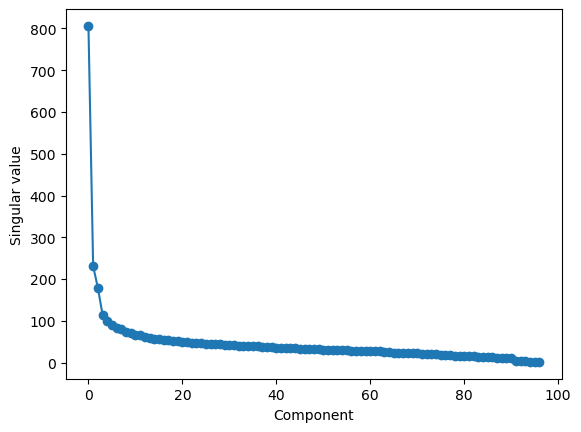

In [ ]:
U, S, Vh = np.linalg.svd(X, full_matrices=False)

plt.plot(S, 'o-')
plt.xlabel("Component")
plt.ylabel("Singular value");

**Exercise**: The first singular value in the plot above was very large and reflects the mean firing rates in the uncentered data. Compute the SVD again on the mean-centered data `X_c` and plot the singular values.

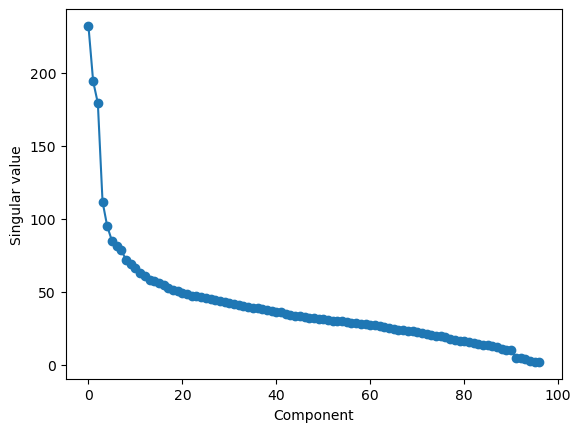

In [ ]:
X_c = X - X.mean(axis=0)
U, S, Vh = np.linalg.svd(X_c, full_matrices=False)

plt.plot(S, 'o-')
plt.xlabel("Component")
plt.ylabel("Singular value");

The raw singular values are hard to interpret. It is often easier to convert them to the percent of variance in the data they explain. The cell below computes the variance explained by each component and converts the result to a percentage.

In [ ]:
n_samples = len(X_c)
var_explained = S**2 / (n_samples-1)
var_explained_ratio = 100 * var_explained / var_explained.sum()

**Exercise**: Re-create the scree plot with the `var_explained_ratio`.

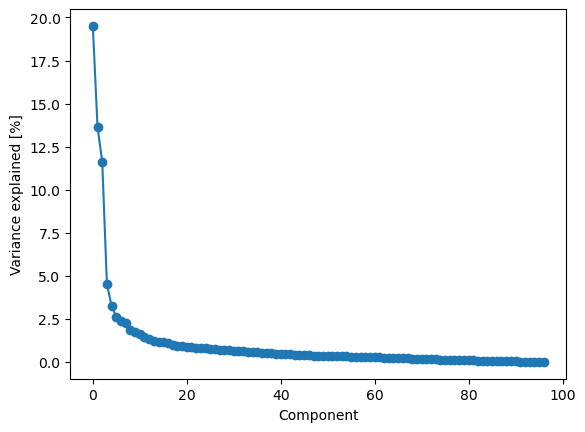

In [ ]:
plt.plot(var_explained_ratio, 'o-')
plt.xlabel("Component")
plt.ylabel("Variance explained [%]");

**Example**: Plot the cumulative sum of the explained variance ratio for the first 10 components. Together these account for about 63% of the variance in the data.

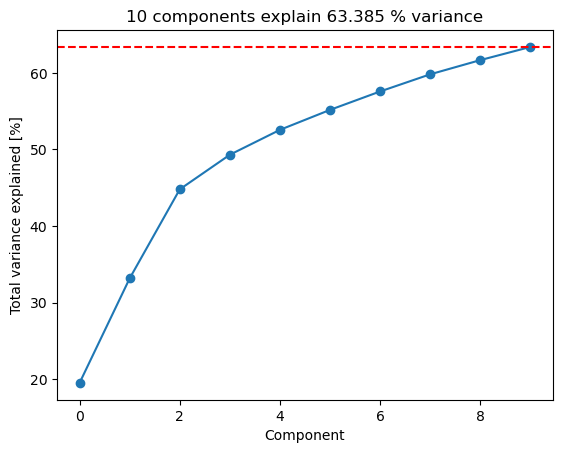

In [ ]:
n_components = 10
total_var_explained = np.cumsum(var_explained_ratio[:n_components])

plt.plot(total_var_explained, 'o-')
plt.axhline(y=total_var_explained[-1], linestyle='--', color="red");
plt.xlabel("Component")
plt.ylabel("Total variance explained [%]")
plt.title(f"{n_components} components explain {total_var_explained[-1]:.3f} % variance");

**Exercise**: Using the approach from the exercise above, find the minimum number of components required to explain 50% and 90% of the variance in the data.

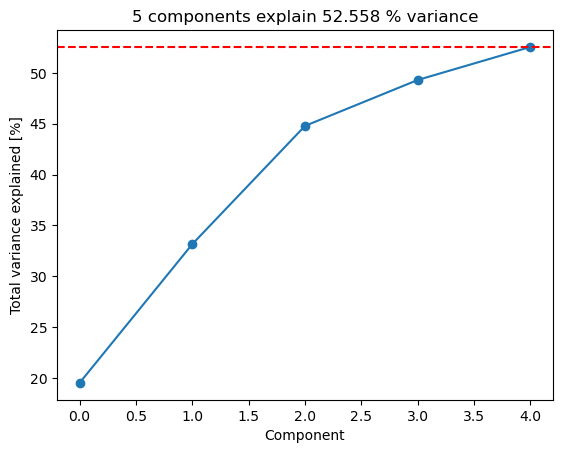

In [ ]:
n_components = 5
total_var_explained = np.cumsum(var_explained_ratio[:n_components])

plt.plot(total_var_explained, 'o-')
plt.axhline(y=total_var_explained[-1], linestyle='--', color="red");
plt.xlabel("Component")
plt.ylabel("Total variance explained [%]")
plt.title(f"{n_components} components explain {total_var_explained[-1]:.3f} % variance");

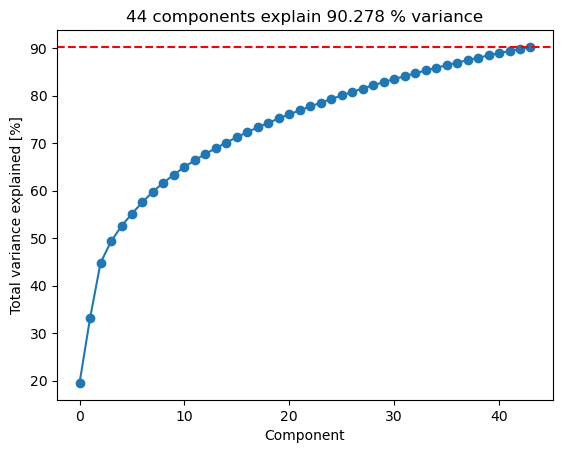

In [ ]:
n_components = 44
total_var_explained = np.cumsum(var_explained_ratio[:n_components])

plt.plot(total_var_explained, 'o-')
plt.axhline(y=total_var_explained[-1], linestyle='--', color="red");
plt.xlabel("Component")
plt.ylabel("Total variance explained [%]")
plt.title(f"{n_components} components explain {total_var_explained[-1]:.3f} % variance");

## Which Neurons Contribute to the Principal Components?

So far, we have used SVD mainly to look at the singular values `S`. We now turn to `Vh`, the matrix that contains the principal component directions. The `np.linalg.svd()` function returns the transpose of $V$, called `Vh`, so each row of `Vh` is one principal component and each column corresponds to one neuron. A large positive or negative loading means that the neuron contributes strongly to that component, whereas values near zero mean it contributes little.

By plotting `Vh` as a heatmap, we can ask whether components are dominated by a few neurons or whether many neurons contribute mixed weights. Sorting neurons by their loading on one component is a visual test for structure: if the same ordering reveals smooth or block-like patterns in other components, that suggests an ordered or modular organization. If the other components look mixed after sorting, that is more consistent with a distributed population code.

We can also use the loading matrix to find individual neurons that have a large weight for a given component. If the principal components capture variance related to the reaching angles, neurons that are assigned a large weight should exhibit strong angle selectivity.

### Code Reference

| Code | Description |
| --- | --- |
| `Vh` | Component/loading matrix with shape `(n_components, n_neurons)` |
| `plt.imshow(Vh, aspect="auto")` | Plot the loading matrix as a heatmap |
| `Vh[:5]` | Select the first five principal components |
| `Vh[component]` | Loadings of all neurons for one component |
| `np.argsort(Vh[component])` | Sort neurons by their loading on one component |
| `Vh[:, sort_idx]` | Reorder all component loadings using the sorted neuron order |
| `np.abs(Vh[component])` | Ignore loading sign and focus on contribution strength |
| `np.argmax(np.abs(Vh[component]))` | Find the neuron with the largest absolute loading for a component |
| `X_3d[:, :, idx].mean(axis=1)` | Average one neuron's firing rate across trials for each reaching angle |

### Exercises

Run the cell below to reload the data and compute SVD on the mean-centered data `X_c` in case the original values were modified.

In [ ]:
X = np.load("data/center_out.npy")
X_c = X - X.mean(axis=0)
U, S, Vh = np.linalg.svd(X_c, full_matrices=False)

**Example**: Plot the component loading matrix `Vh` for all components with a colorbar that encodes the component loading. The larger a neuron's loading (positive or negative), the more it contributes to the given component.

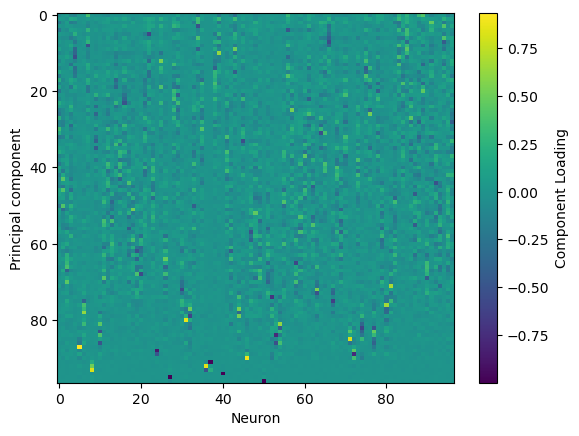

In [ ]:
plt.imshow(Vh, aspect="auto");
plt.colorbar(label="Component Loading")
plt.xlabel("Neuron")
plt.ylabel("Principal component");

**Exercise**: Plot the loading matrix only for the first 5 components in `Vh`.

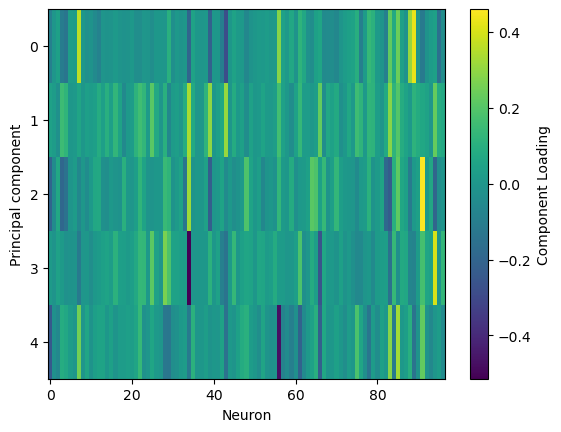

In [ ]:
plt.imshow(Vh[:5], aspect="auto");
plt.colorbar(label="Component Loading")
plt.xlabel("Neuron")
plt.ylabel("Principal component");

**Example**: Sort the loading matrix by the weights of the first component.

In [ ]:
sort_idx = np.argsort(Vh[0])
Vh_sorted = Vh[:,sort_idx]

**Exercise**: Plot the sorted loading matrix for the first 5 components. If reaching angle is represented by a spatially ordered code, sorting by one component should also reveal a pattern in other components. If the code is distributed, we would expect no such patterns.

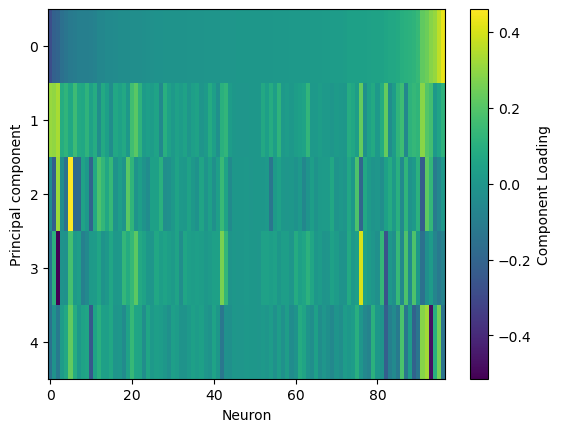

In [ ]:
plt.imshow(Vh_sorted[:5], aspect="auto");
plt.colorbar(label="Component Loading")
plt.xlabel("Neuron")
plt.ylabel("Principal component")

**Exercise**: Sort the loading matrix by the weights of the third component and plot the sorted loading matrix for the first 5 components. Is the result more compatible with an ordered or a distributed code?

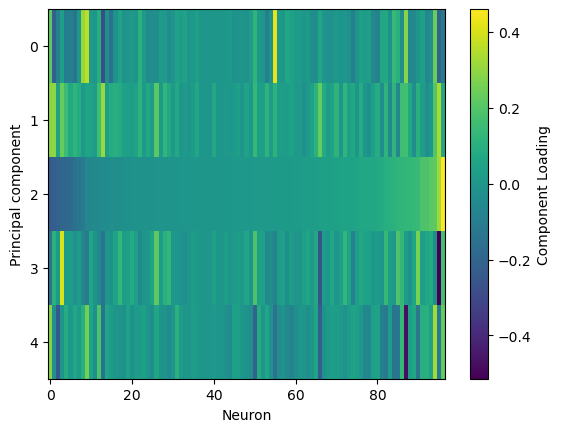

In [ ]:
sort_idx = np.argsort(Vh[2])
Vh_sorted = Vh[:,sort_idx]

plt.imshow(Vh_sorted[:5], aspect="auto");
plt.colorbar(label="Component Loading")
plt.xlabel("Neuron")
plt.ylabel("Principal component");

**Example**: Find the neuron with the largest absolute weight for component 0 and plot the firing rate of that neuron for every condition. If the component captures variance related to the reaching angle that neuron should exhibit strong selectivity.

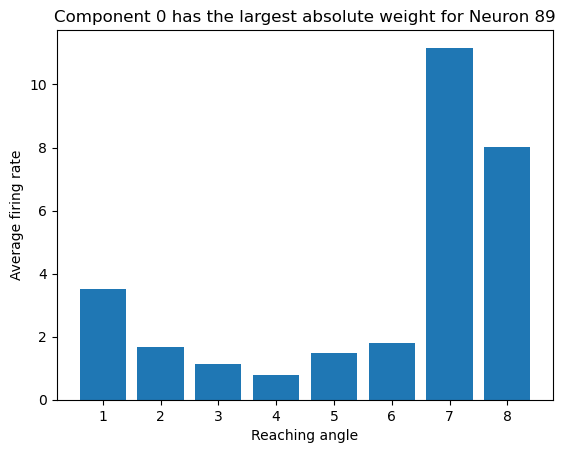

In [ ]:
component = 0
idx = np.argmax(np.abs(Vh[component]))

plt.bar(x=np.arange(1, 9), height=X_3d[:, :, idx].mean(axis=1))
plt.xlabel("Reaching angle")
plt.ylabel("Average firing rate");
plt.title(f"Component {component} has the largest absolute weight for Neuron {idx}");

**Exercise**: Use the approach from above to find the neurons with the largest absolute weights for components 1 and 2 and plot their response profile. What is the preferred angle of those neurons?

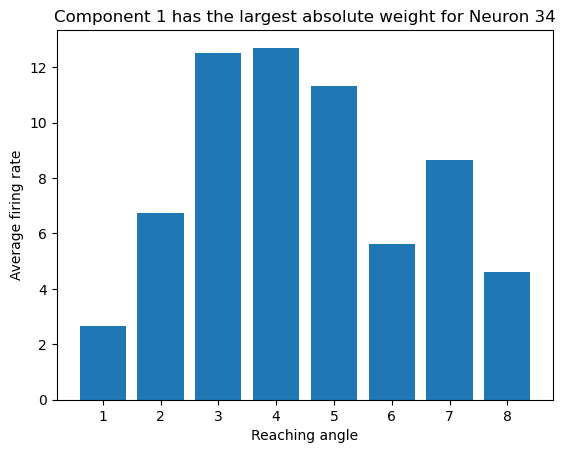

In [ ]:
component = 1
idx = np.argmax(np.abs(Vh[component]))

plt.bar(x=np.arange(1, 9), height=X_3d[:, :, idx].mean(axis=1))
plt.xlabel("Reaching angle")
plt.ylabel("Average firing rate");
plt.title(f"Component {component} has the largest absolute weight for Neuron {idx}");

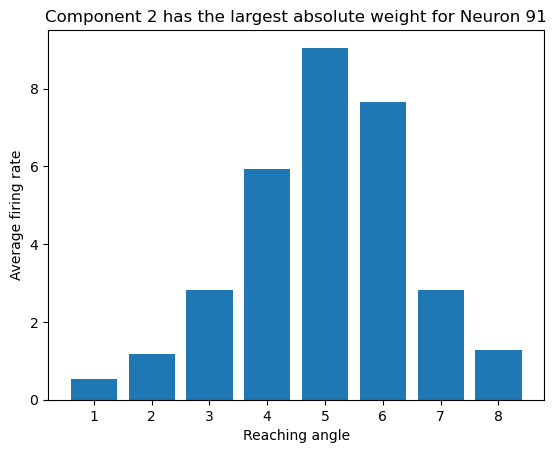

In [ ]:
component = 2
idx = np.argmax(np.abs(Vh[component]))

plt.bar(x=np.arange(1, 9), height=X_3d[:, :, idx].mean(axis=1))
plt.xlabel("Reaching angle")
plt.ylabel("Average firing rate");
plt.title(f"Component {component} has the largest absolute weight for Neuron {idx}");

## Exploring Component Weights and Scores

In the previous section, we examined the loading matrix `Vh`, which tells us how each neuron contributes to a principal component. We now turn to the complementary question: how strongly is each **trial** expressed along those components? In the SVD of the centered data matrix, this information is contained in `U`, whose columns give the normalized trial weights for each component.

By plotting these trial weights, we can ask whether certain principal components are associated with specific reaching angles. Averaging the weights across trials of the same angle makes these patterns easier to see. We then convert the normalized weights into **component scores** with `Z = U S`, which scales each component according to how much variance it explains and gives the coordinates of each trial in PCA space.

### Code Reference

| Code | Description |
| --- | --- |
| `U[:, k]` | Normalized trial weights for component `k` |
| `plt.plot(U[:, k], marker="o", linestyle="none")` | Plot one component's trial weights across all trials |
| `range(0, len(U), 91)` | Step through the trial blocks for the 8 reaching angles |
| `plt.axvspan(start, end, color=..., alpha=0.15)` | Shade the trial range belonging to one reaching angle |
| `U.reshape(n_angles, -1, n_components)` | Reshape the trial-weight matrix into angle x trial x component format |
| `U_3d.mean(axis=1)` | Average trial weights across trials within each reaching angle |
| `Z_3d = U_3d * S` | Convert normalized trial weights into component scores |
| `Z_3d.mean(axis=1)` | Average component scores across trials within each reaching angle |

### Exercises

Run the cell below to reload the data and compute SVD on the mean-centered data `X_c` in case the original values were modified.

In [ ]:
X = np.load("data/center_out.npy")
X_c = X - X.mean(axis=0)
U, S, Vh = np.linalg.svd(X_c, full_matrices=False)

**Example**: Plot the trial weights for the first component (i.e. the first column of `U`). Each dot is one trial, and the y-value represents the normalized weight of that trial on the component. This component appears to be strongly expressed for trials from angles 7 and 8.

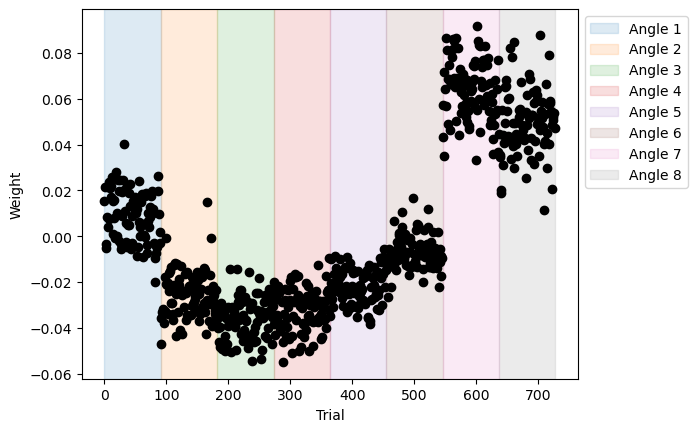

In [ ]:
plt.plot(U[:, 0], color="black", marker="o", linestyle="none")

for angle, start in enumerate(range(0, len(U), 91)):
    end = start + 91 # 91 trials per angle
    plt.axvspan(start, end, color=f"C{angle}", alpha=0.15, label=f"Angle {angle+1}")

plt.xlabel("Trial")
plt.ylabel("Weight")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1));

**Exercise**: Using the approach from above, plot the trial weights for the 2nd and 3rd component. Which reaching angles do these components capture?

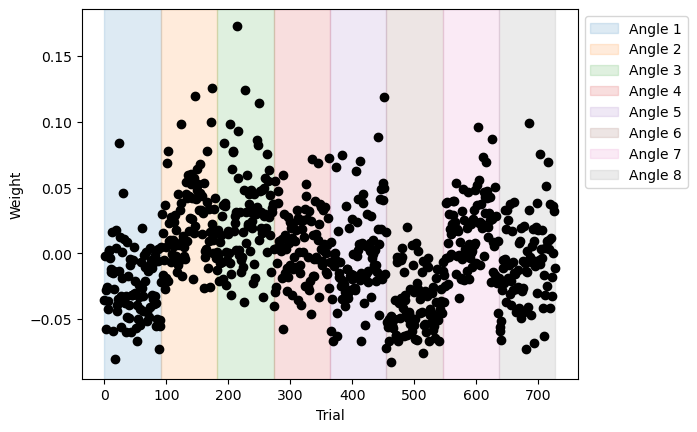

In [ ]:
plt.plot(U[:, 1], color="black", marker="o", linestyle="none")

for angle, start in enumerate(range(0, len(U), 91)):
    end = start + 91 # 91 trials per angle
    plt.axvspan(start, end, color=f"C{angle}", alpha=0.15, label=f"Angle {angle+1}")

plt.xlabel("Trial")
plt.ylabel("Weight")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1));

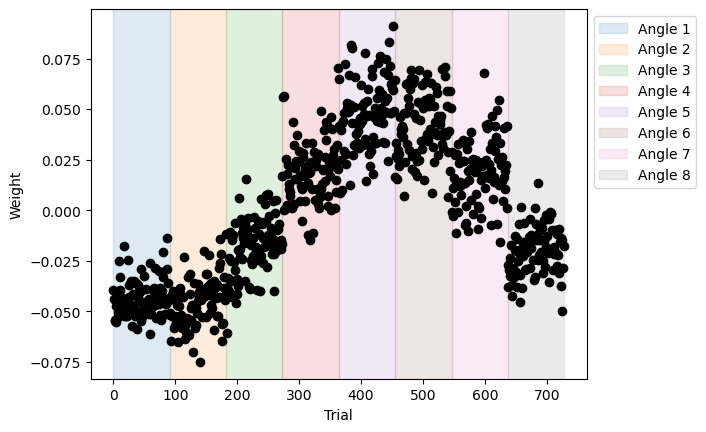

In [ ]:
plt.plot(U[:, 2], color="black", marker="o", linestyle="none")

for angle, start in enumerate(range(0, len(U), 91)):
    end = start + 91 # 91 trials per angle
    plt.axvspan(start, end, color=f"C{angle}", alpha=0.15, label=f"Angle {angle+1}")

plt.xlabel("Trial")
plt.ylabel("Weight")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1));

For plotting different conditions, it is useful to reshape `U` into a 3D array shaped `(n_angles, n_trials, n_components)`. Run the cell below to create `U_3d`.

In [ ]:
n_angles = 8
n_components = U.shape[1]
U_3d = U.reshape(n_angles, -1, n_components)

f"n_angles, n_trials, n_components: {U_3d.shape}"

'n_angles, n_trials, n_components: (8, 91, 97)'

**Example**: Plot the average trial weight for every reaching angle for the first component. This representation is less noisy compared to plotting individual trials.

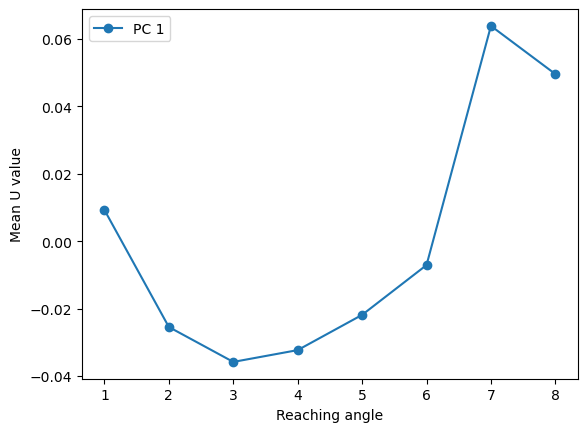

In [ ]:
angles = np.arange(1, n_angles + 1)
plt.plot(angles, U_3d.mean(axis=1)[:, 0], 'o-', label=f"PC 1")

plt.xlabel("Reaching angle")
plt.ylabel("Mean U value")
plt.legend();

**Exercise**: Recreate the plot from above but add components 2 through 4.

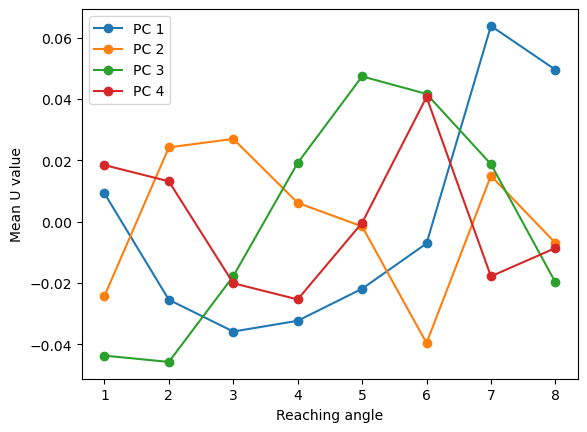

In [ ]:
angles = np.arange(1, n_angles + 1)
plt.plot(angles, U_3d.mean(axis=1)[:, 0], 'o-', label=f"PC 1")
plt.plot(angles, U_3d.mean(axis=1)[:, 1], 'o-', label=f"PC 2")
plt.plot(angles, U_3d.mean(axis=1)[:, 2], 'o-', label=f"PC 3")
plt.plot(angles, U_3d.mean(axis=1)[:, 3], 'o-', label=f"PC 4")

plt.xlabel("Reaching angle")
plt.ylabel("Mean U value")
plt.legend();

The weights in `U` are normalized which means that all components have the same amplitude regardless of how much variance they explain. To convert the weights to scores we have to multiply them by their singular values `S`.

In [ ]:
Z_3d = U_3d * S

**Exercise**: Recreate the plot from above but use the `Z_3d` array instead of `U_3d`. The curves will have the same shape but they are scaled by their singular value which indicates how much information the component is capturing.

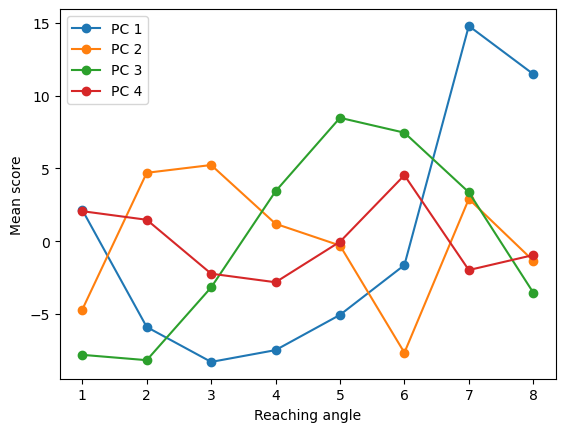

In [ ]:
angles = np.arange(1, n_angles + 1)
plt.plot(angles, Z_3d.mean(axis=1)[:, 0], 'o-', label=f"PC 1")
plt.plot(angles, Z_3d.mean(axis=1)[:, 1], 'o-', label=f"PC 2")
plt.plot(angles, Z_3d.mean(axis=1)[:, 2], 'o-', label=f"PC 3")
plt.plot(angles, Z_3d.mean(axis=1)[:, 3], 'o-', label=f"PC 4")

plt.xlabel("Reaching angle")
plt.ylabel("Mean score")
plt.legend();

## Visualize the Data in PCA-Space

So far, we have examined principal components in terms of their singular values, neuron loadings, and trial weights. We now bring these pieces together by projecting the trial activity patterns into the low-dimensional space spanned by the principal components themselves. In this representation, each trial becomes a point in PCA space, with coordinates given by its scores on the selected components.

If the neural population activity contains structure related to reaching direction, trials from the same angle should occupy similar locations in this low-dimensional space. Plotting the trials in the first few principal components therefore lets us ask whether the 97-dimensional activity patterns cluster by condition and whether the geometry of those clusters reflects the circular structure of the 8 reaching angles.

### Code Reference

| Code | Description |
| --- | --- |
| `X_c @ Vh.T[:, i:j]` | Project the centered trial data into a selected range of principal-component directions |
| `X_proj.reshape(n_angles, -1, X_proj.shape[-1])` | Reshape projected trials into angle x trial x component format |
| `fig.add_subplot(111, projection="3d")` | Create a 3D axis for PCA-space visualization |
| `ax.scatter(x, y, z, c=f"C{angle}", label=...)` | Plot one reaching angle as a colored cluster in PCA space |
| `X_proj_3d.mean(axis=1)` | Compute one centroid per reaching angle by averaging across trials |
| `ax.view_init(elev=20, azim=40)` | Set the camera angle for the 3D plot |

### Exercises


Run the cell below to reload the data and compute SVD on the mean-centered data `X_c` in case the original values were modified.

In [ ]:
X = np.load("data/center_out.npy")
X_c = X - X.mean(axis=0)
U, S, Vh = np.linalg.svd(X_c, full_matrices=False)

**Example**: Project all 728 trials into the PC directions 4 to 6 and print the shape of `X_proj`.

In [ ]:
X_proj = X_c @ Vh.T[:, 3:6]

f"n_trials, n_components: {X_proj.shape}"

'n_trials, n_components: (728, 3)'

**Example**: Reshape `X_proj` to a 3D array, plot the trials in the 3-dimensional PC space and highlight them by reaching angle. It appears that these components do not capture much of the angle-related structure.

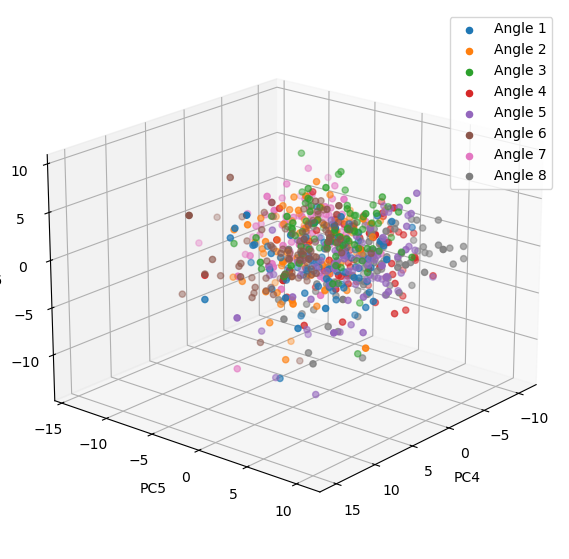

In [ ]:
n_angles = 8
X_proj_3d = X_proj.reshape(n_angles, -1, X_proj.shape[-1])

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

for angle in range(n_angles):
    ax.scatter(
        X_proj_3d[angle, :, 0],
        X_proj_3d[angle, :, 1],
        X_proj_3d[angle, :, 2],
        c=f"C{angle}",
        label=f"Angle {angle + 1}",
    )
ax.legend()
ax.set(xlabel="PC4", ylabel="PC5", zlabel="PC6")
ax.view_init(elev=20, azim=40)

**Exercise**: Following the examples from above, project all 728 trials into the first 3 PC directions, plot the trials in the 3-dimensional PC space and highlight them by reaching angle. Do the conditions form clusters now?

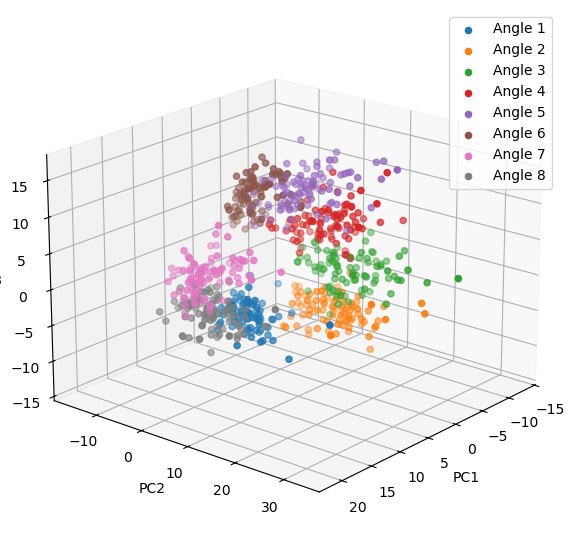

In [ ]:
X_proj = X_c @ Vh.T[:, :3]

n_angles = 8
X_proj_3d = X_proj.reshape(n_angles, -1, X_proj.shape[-1])

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

for angle in range(n_angles):
    ax.scatter(
        X_proj_3d[angle, :, 0],
        X_proj_3d[angle, :, 1],
        X_proj_3d[angle, :, 2],
        c=f"C{angle}",
        label=f"Angle {angle + 1}",
    )
ax.legend()
ax.set(xlabel="PC1", ylabel="PC2", zlabel="PC3")
ax.view_init(elev=20, azim=40)


**Exercise**: Plotting each trial makes the plot quite noisy. Recreate the 3D plot from above but use the `centroids` (i.e. the average across the trial dimension) instead of `X_proj` (**Hint**: the `centroids` array is 2-dimensional).


In [ ]:
centroids = X_proj_3d.mean(axis=1)

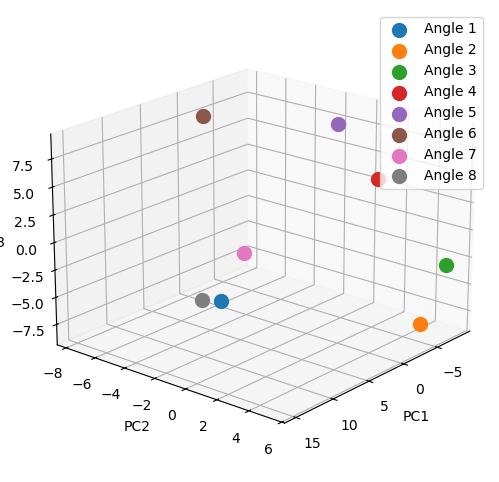

In [ ]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

for angle in range(n_angles):
    ax.scatter(
        centroids[angle, 0],
        centroids[angle, 1],
        centroids[angle, 2],
        s=100,
        label=f"Angle {angle + 1}",
    )

ax.legend()
ax.set(xlabel="PC1", ylabel="PC2", zlabel="PC3")
ax.view_init(elev=20, azim=40)

**Bonus**: The cell below defines a loop by adding a copy the first centroid to the end. Use `plt.plot()` to draw lines using the coordinates in `c_loop` to highlight the ring-like structure of the data.

In [ ]:
c_loop = np.vstack([centroids, centroids[0]])
c_loop


array([[ 2.14105397, -4.70407455, -7.82215307],
       [-5.90830869,  4.69934852, -8.18923484],
       [-8.30935234,  5.23527909, -3.18271452],
       [-7.49668181,  1.19170121,  3.4292888 ],
       [-5.07261273, -0.3025939 ,  8.4825433 ],
       [-1.64799658, -7.67376368,  7.45860454],
       [14.80281845,  2.9002032 ,  3.36025966],
       [11.49107972, -1.3460999 , -3.53659387],
       [ 2.14105397, -4.70407455, -7.82215307]])

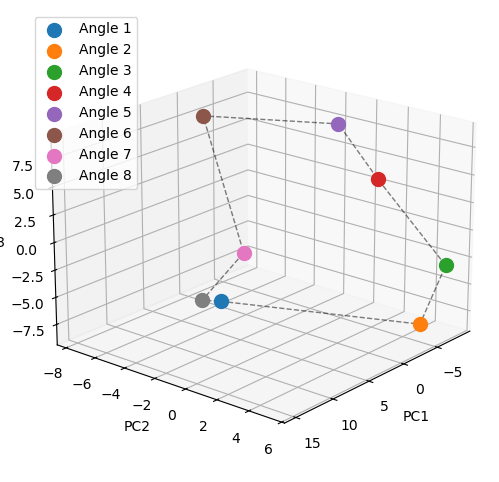

In [ ]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

for angle in range(n_angles):
    ax.scatter(
        centroids[angle, 0],
        centroids[angle, 1],
        centroids[angle, 2],
        s=100,
        label=f"Angle {angle + 1}",
    )

c_loop = np.vstack([centroids, centroids[0]])
ax.plot(c_loop[:, 0], c_loop[:, 1], c_loop[:, 2], "k--", lw=1, alpha=0.5)

ax.legend()
ax.set(xlabel="PC1", ylabel="PC2", zlabel="PC3")
ax.view_init(elev=20, azim=40)

## (Bonus) PCA on Simulated Network Dynamics

The PMd analysis treated each trial as a single static snapshot (one 200 ms spike count vector). PCA can also be applied to **time-varying** population activity, revealing the temporal geometry of neural responses.

Here we use a large-scale recurrent network simulation. The network has 10,000 neurons. Three different stimuli (A, B and C) are presented in 300ms intervals. Each stimulus activates one subset of 2400 neurons. The remaining 2800 neurons respond indirectly to the inputs of the other neurons. The model setup is visualized in the image below:

![Visualization of the Simulation](img/model_setup.png)

We align spike trains to each stimulus onset, bin them into 10 ms bins over a 200 ms window, and average over trials to obtain a peri-stimulus time histogram (PSTH) for each neuron. Concatenating the PSTHs across stimuli gives us the data matrix on which PCA is applied.

With the PSTH data matrix assembled, we apply SVD to the mean-centered data matrix and plot the result as **population trajectories**: curves in the top-3 PC space, one curve per stimulus, parameterised by time.

This section won't contain new information with respect to how PCA works. Rather, you'll apply what you have learned so far to a new dataset.

### Code Reference

| Code | Description |
| --- | --- |
| `utils.compute_psth(spike_times, stim_onsets[k], t_bin=10)` | Compute a PSTH for the kth stimulus condition |
| `X_net - X_net.mean(axis=0)` | Mean-center the network data across time bins |
| `U, S, Vh = np.linalg.svd(X_net_c, full_matrices=False)` | Compute the compact SVD of the centered network matrix |
| `S**2 / (len(X_net_c) - 1)` | Convert singular values into variance explained |
| `Z = U * S` | Compute the component scores for all time bins |
| `X_net_c @ Vh.T` | Project the centered data directly into PC-space |
| `np.sqrt(np.sum((zA - zB)**2, axis=1))` | Compute the time-resolved Euclidean distance between two trajectories |

### Exercises


Run the cell below to load the data. This is a randomly sampled subset from the simulated neurons that do not respond directly to the stimuli. `spike_times` contains an array of spike times for every neuron and `stim_onsets` contains the stimulus onsets for all three conditions (A, B and C).

In [ ]:
spike_times = np.load('data/network_spikes.npy', allow_pickle=True)
stim_onsets  = np.load('data/network_stim_on.npy')

print("Number of neurons: ", len(spike_times))
print("Number of conditions: ", stim_onsets.shape[0])
print("Stimulus presentations per condition: ", stim_onsets.shape[1])

Number of neurons:  100
Number of conditions:  3
Stimulus presentations per condition:  1100


**Example**: Create a per-stimulus time histogram (PSTH) for the onsets of stimulus A (`stim_onsets[0]`) with a bin size of 10 ms, store it in `psth_A` and plot it.

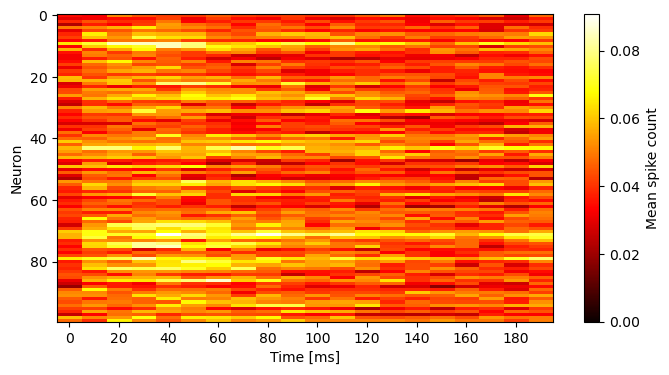

In [ ]:
psth_A, bin_edges = utils.compute_psth(spike_times, stim_onsets[0], t_bin=10)
utils.plot_psth(psth_A, bin_edges)


**Exercise**: Create the PSTHs for stimulus B and C called `psth_B` and `psth_C` and plot them.

**Important**: All PSTHs must be computed with the same bin size so if you change the binsize on one of them you have to adjust the others!

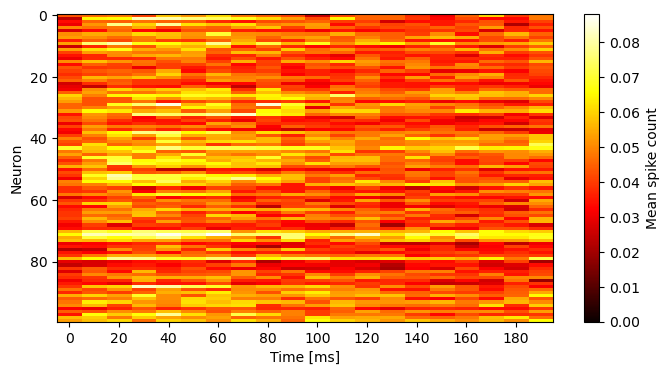

In [ ]:
psth_B, bin_edges = utils.compute_psth(spike_times, stim_onsets[1], t_bin=10)
utils.plot_psth(psth_B, bin_edges)

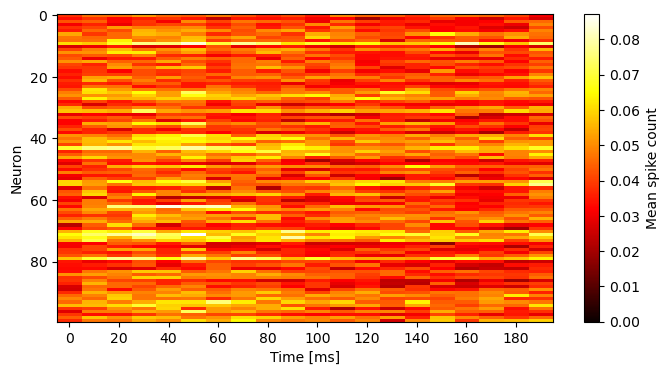

In [ ]:
psth_C, bin_edges = utils.compute_psth(spike_times, stim_onsets[2], t_bin=10)
utils.plot_psth(psth_C, bin_edges)

There clearly is some structure in that data: individual neurons respond differently to the experimental conditions. We can use PCA to capture this structure in a low dimensional space!
To apply PCA, we must first concatenate the three PSTHs into a single array and transpose it to get an array shaped `(n_bins*3, n_neurons)`. The `assert` statement makes sure that our array matches the expected shape.

In [ ]:
X_net = np.concatenate([psth_A, psth_B, psth_C], axis=1).T

n_neurons, n_bins = psth_A.shape
assert X_net.shape == (n_bins*3, n_neurons)

**Exercise**: Mean-center `X_net` and compute the SVD. Plot the singular values for the first 20 components.

**Bonus**: Convert the singular values to percent of variance explained.

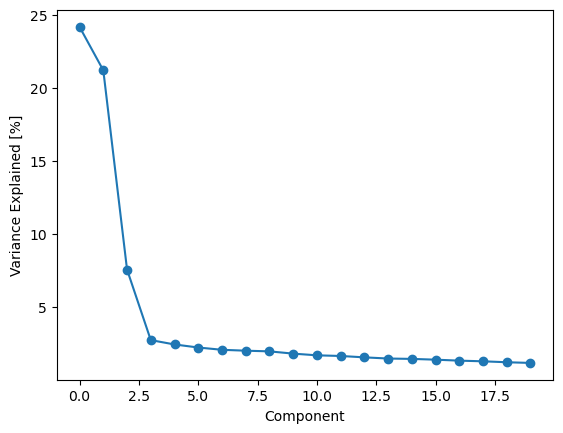

In [ ]:
X_net_c = X_net - X_net.mean(axis=0)

U, S, Vh = np.linalg.svd(X_net_c, full_matrices=False)
var_exp = S**2 / (len(X_net_c) - 1)
var_exp_percent = 100 * var_exp / var_exp.sum()

plt.plot(var_exp_percent[:20], "o-")
plt.xlabel("Component")
plt.ylabel("Variance Explained [%]");

**Exercise**: Compute the component scores `Z` by multiplying the normalized trial weights `U` with the singular values.

In [ ]:
Z = U * S

**Example**: Extract the scores corresponding to stimulus A (i.e. the first `n_bins`) and store them in `zA`. Then, plot the scores of the first 3 components in `zA`. This shows how the representation of the stimulus evolves across time in PCA space.

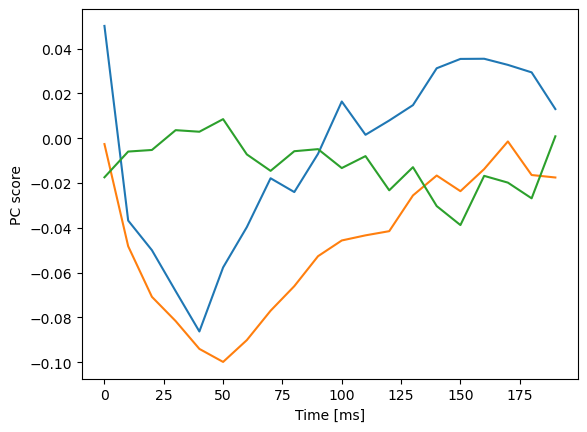

In [ ]:
zA = Z[:n_bins]

plt.plot(bin_edges[:-1], zA[:, :3]);
plt.ylabel("PC score")
plt.xlabel("Time [ms]");

**Exercise**: Extract the scores corresponding to stimulus B (i.e. the second `n_bins`) and store them in `zB`. Then, plot the scores of the first 3 components in `zB`.

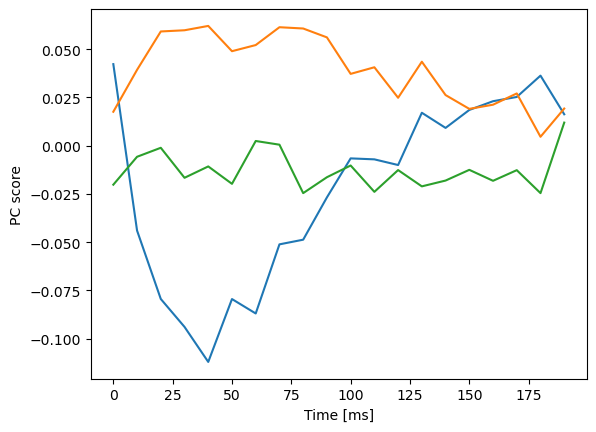

In [ ]:
zB = Z[n_bins: 2*n_bins]

plt.plot(bin_edges[:-1], zB[:, :3]);
plt.ylabel("PC score")
plt.xlabel("Time [ms]");

**Exercise**: Extract the scores corresponding to stimulus C (i.e. the last `n_bins`) and store them in `zC`. Then, plot the scores of the first 3 components in `zC`. Does the temporal evolution of the component scores look similar for all conditions?

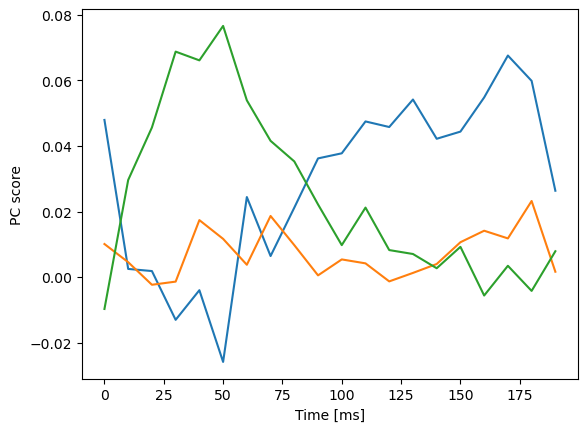

In [ ]:
zC = Z[2*n_bins:]

plt.plot(bin_edges[:-1], zC[:, :3]);
plt.ylabel("PC score")
plt.xlabel("Time [ms]");

**Example**: Compute the Euclidean distance between the component scores for stimuli A and B. This shows how different the representation of the conditions is in PCA space across time.

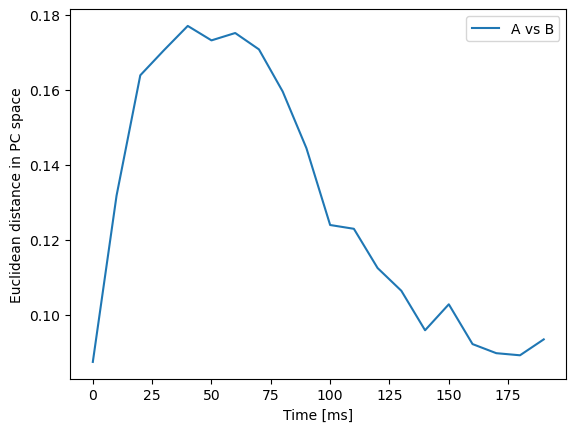

In [ ]:
dist_AB = np.sqrt(np.sum((zA - zB)**2, axis=1))

plt.plot(bin_edges[:-1], dist_AB, label="A vs B")
plt.xlabel('Time [ms]')
plt.ylabel('Euclidean distance in PC space')
plt.legend();

**Exercise**: Add the Euclidean distance between A and C as well as between B and C to the plot. Do they all follow a similar trajectory?

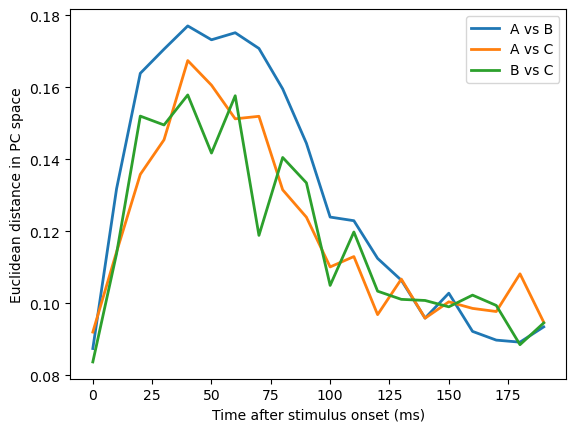

In [ ]:
trajs = [zA, zB, zC]
labels_dist = ['A vs B', 'A vs C', 'B vs C']
pairs = [(0, 1), (0, 2), (1, 2)]

for (i, j), lbl in zip(pairs, labels_dist):
    dist = np.sqrt(np.sum((trajs[i] - trajs[j])**2, axis=1))
    plt.plot(bin_edges[:-1], dist, lw=2, label=lbl)

plt.xlabel('Time after stimulus onset (ms)')
plt.ylabel('Euclidean distance in PC space')
plt.legend();

**Example**: Project `X_net_c` into the first 3 principal-component directions using `Vh`, then plot the resulting 3D trajectory for stimulus A.

In [ ]:
X_proj = X_net_c @ Vh.T[:, :3]
X_proj_3d = X_proj.reshape(3, n_bins, -1)

f"n_conditions, n_bins, n_components: {X_proj_3d.shape}"

'n_conditions, n_bins, n_components: (3, 20, 3)'

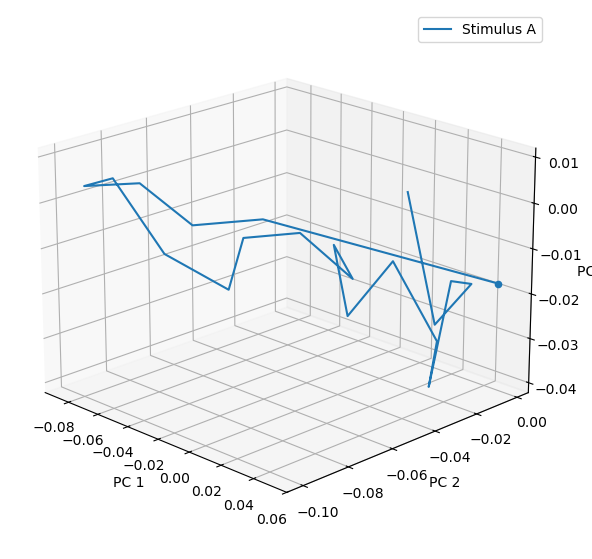

In [ ]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(X_proj_3d[0, :, 0], X_proj_3d[0, :, 1], X_proj_3d[0, :, 2], label="Stimulus A")
ax.scatter(X_proj_3d[0, 0, 0], X_proj_3d[0, 0, 1], X_proj_3d[0, 0, 2])  # start dot

ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.set_zlabel('PC 3')
ax.legend()
ax.view_init(elev=20, azim=-45)

**Exercise**: Plot the 3D trajectories for all stimuli.

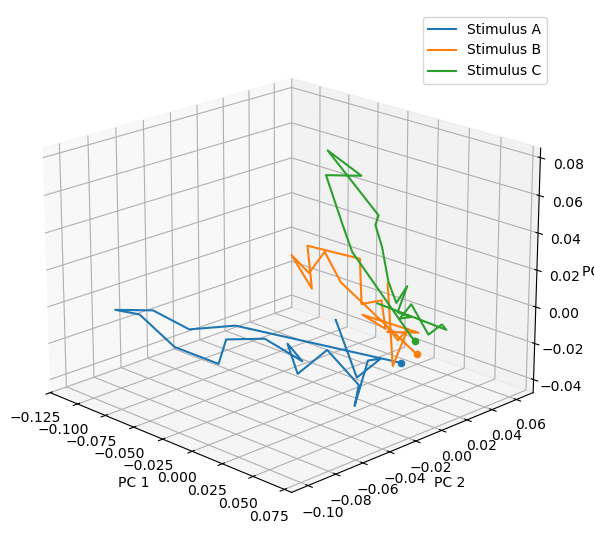

In [ ]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
stimuli = ["A", "B", "C"]
for i in range(3):
    ax.plot(X_proj_3d[i, :, 0], X_proj_3d[i, :, 1], X_proj_3d[i, :, 2], label=f"Stimulus {stimuli[i]}")
    ax.scatter(X_proj_3d[i, 0, 0], X_proj_3d[i, 0, 1], X_proj_3d[i, 0, 2] ) # start dot

ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.set_zlabel('PC 3')
ax.legend()
ax.view_init(elev=20, azim=-45)

## Reflection

In this session we applied PCA to two very different neural datasets and found a consistent result: both the static planning-period activity in PMd (across 728 trials) and the time-varying network responses (across 20 time bins per stimulus) live in a low-dimensional subspace — roughly 3–8 dimensions out of 97 or 100.

However, PCA has an important limitation: it does not include an explicit noise model. In real neural data, neurons have very different baseline firing rates and different noise levels, so a neuron firing at 30 spikes/s can dominate the covariance matrix relative to a neuron at 1 spike/s, even if both are equally informative about the latent state.

In Session 2 we will see how **probabilistic PCA** (PPCA) and **Factor Analysis** (FA) address this by learning per-neuron noise levels, and how this leads naturally to GPFA — the temporal extension that gives smooth single-trial trajectories.